In [1]:

from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate, cross_val_score, cross_val_predict
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_error, max_error

from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression

# from data_to_bigquery import load_from_bigquery

%matplotlib inline

In [2]:
def load_from_bigquery(PROJECT: str, DATASET: str, TABLE: str):
    '''
    Load data from BigQuery into a pandas DataFrame.

    Arguments:
        PROJECT: GCP project ID
        DATASET: BigQuery dataset name
        TABLE: BigQuery table name

    Returns: pandas DataFrame
    '''

    client = bigquery.Client(project=PROJECT)

    query = f'''
    SELECT *
    FROM `{PROJECT}.{DATASET}.{TABLE}`
    '''

    df = client.query(query).to_dataframe()

    rows, cols = df.shape
    print(f'Loaded {rows:,} rows and {cols} columns from {PROJECT}.{DATASET}.{TABLE}')

    return df

In [3]:
df = load_from_bigquery('gridzero-489711', 'merged_set', 'Fully_merged_dataset_2025')

/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Loaded 17,519 rows and 23 columns from gridzero-489711.merged_set.Fully_merged_dataset_2025


In [4]:
print(f'Shape: {df.shape}')
print(f'Nulls:\n{df.isnull().sum()}')
print(f'Duplicates: {df.duplicated().sum()}')

Shape: (17519, 23)
Nulls:
time                                0
temperature_2m_c                    0
wind_speed_100m_ms                  0
wind_gusts_10m_ms                   0
cloud_cover_pct                     0
shortwave_radiation_wm2             0
direct_radiation_wm2                0
diffuse_radiation_wm2               0
pressure_msl_hpa                    0
snowfall_cm                         0
Biomass                            45
Fossil Gas                         45
Fossil Hard coal                   45
Fossil Oil                         45
Hydro Pumped Storage               45
Hydro Run-of-river and poundage    45
Nuclear                            45
Other                              45
Solar                              45
Wind Offshore                      45
Wind Onshore                       45
TotalOutput-MW                     45
carbon_intensity                   47
dtype: int64
Duplicates: 0


In [5]:
df['Fossil Gas']

0        3607.0
1        3854.0
2        3867.0
3        3726.0
4        3682.0
          ...  
17514    7176.0
17515    6792.0
17516    6535.0
17517    6641.0
17518       NaN
Name: Fossil Gas, Length: 17519, dtype: float64

In [6]:
cols = [df.columns]
cols

[Index(['time', 'temperature_2m_c', 'wind_speed_100m_ms', 'wind_gusts_10m_ms',
        'cloud_cover_pct', 'shortwave_radiation_wm2', 'direct_radiation_wm2',
        'diffuse_radiation_wm2', 'pressure_msl_hpa', 'snowfall_cm', 'Biomass',
        'Fossil Gas', 'Fossil Hard coal', 'Fossil Oil', 'Hydro Pumped Storage',
        'Hydro Run-of-river and poundage', 'Nuclear', 'Other', 'Solar',
        'Wind Offshore', 'Wind Onshore', 'TotalOutput-MW', 'carbon_intensity'],
       dtype='object')]

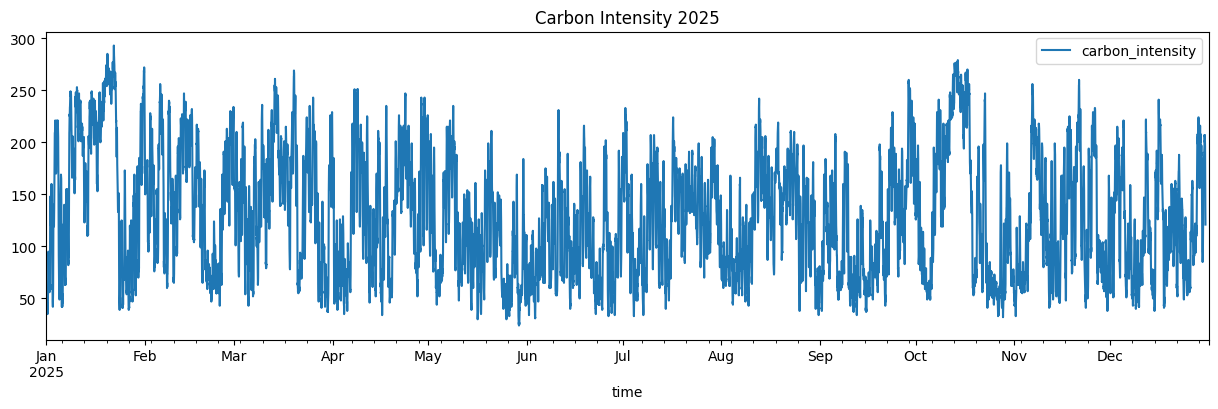

In [7]:

df.plot(x='time', y='carbon_intensity', figsize=(15,4))
plt.title('Carbon Intensity 2025')
plt.show()

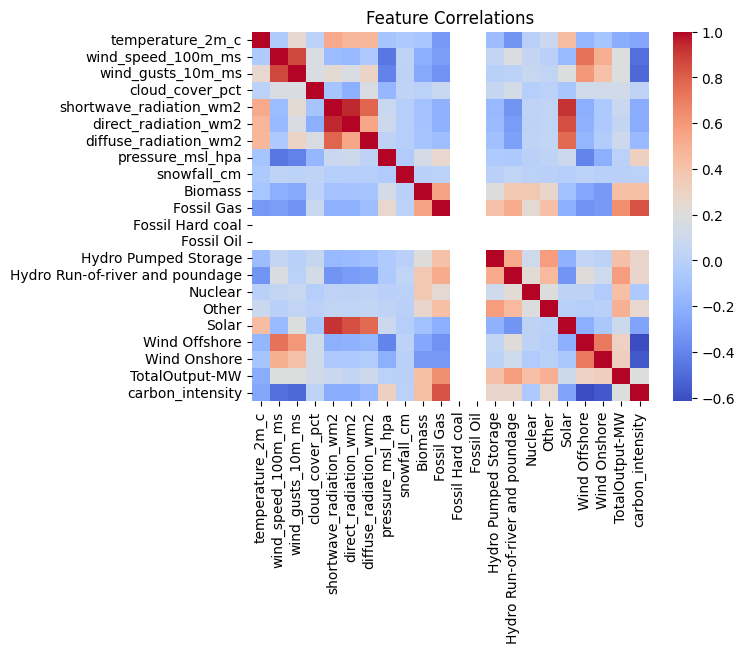

In [8]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap='coolwarm')
plt.title('Feature Correlations')
plt.show()

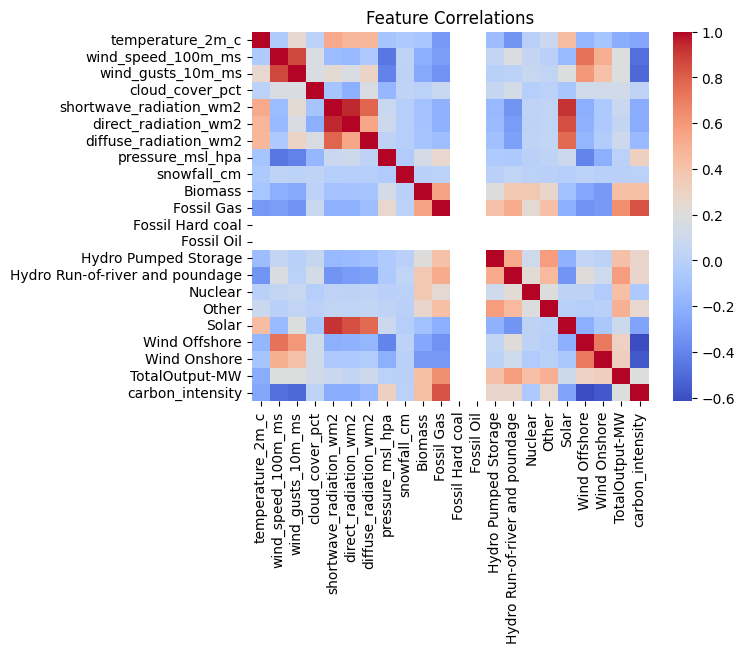

In [9]:
feat_corr_matrix_plot, ax = plt.subplots()

corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap='coolwarm', ax = ax)
plt.title('Feature Correlations')
plt.show()

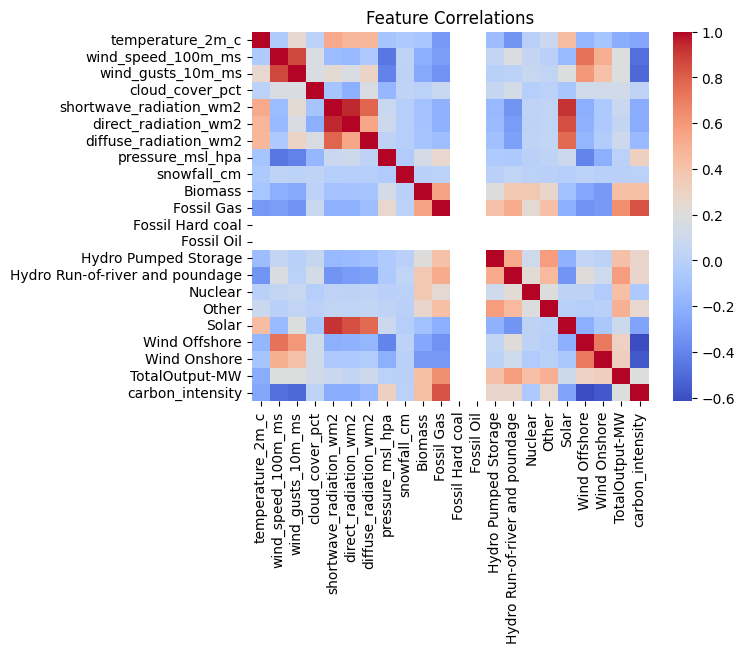

In [10]:
feat_corr_matrix_plot

In [11]:
load_from_bigquery('gridzero-489711', 'merged_set', 'Fully_merged_dataset_2025')

/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Loaded 17,519 rows and 23 columns from gridzero-489711.merged_set.Fully_merged_dataset_2025


,time,temperature_2m_c,wind_speed_100m_ms,wind_gusts_10m_ms,cloud_cover_pct,shortwave_radiation_wm2,direct_radiation_wm2,diffuse_radiation_wm2,pressure_msl_hpa,snowfall_cm,...,Fossil Oil,Hydro Pumped Storage,Hydro Run-of-river and poundage,Nuclear,Other,Solar,Wind Offshore,Wind Onshore,TotalOutput-MW,carbon_intensity
0,2025-01-01 00:00:00+00:00,10.5,48.0,55.1,100,0.0,0.0,0.0,1014.2,0.0,...,0.0,0.0,736.0,5065.0,183.0,0.0,11444.531,9113.028,31028.559,55
1,2025-01-01 00:30:00+00:00,10.5,48.0,55.1,100,0.0,0.0,0.0,1014.2,0.0,...,0.0,0.0,745.0,5063.0,290.0,0.0,11138.565,8969.868,31138.433,54
2,2025-01-01 01:00:00+00:00,11.1,46.3,58.3,100,0.0,0.0,0.0,1013.1,0.0,...,0.0,0.0,746.0,5056.0,333.0,0.0,10788.770,8931.922,30826.692,53
3,2025-01-01 01:30:00+00:00,11.1,46.3,58.3,100,0.0,0.0,0.0,1013.1,0.0,...,0.0,0.0,746.0,5060.0,238.0,0.0,10519.534,8810.976,30209.510,53
4,2025-01-01 02:00:00+00:00,11.1,43.6,60.5,100,0.0,0.0,0.0,1012.0,0.0,...,0.0,0.0,747.0,5056.0,277.0,0.0,10706.056,8456.386,29988.442,47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17514,2025-12-31 21:00:00+00:00,-0.8,22.5,23.4,5,0.0,0.0,0.0,1023.1,0.0,...,0.0,4.0,378.0,4082.0,743.0,0.0,10803.097,5827.825,31071.922,<NA>
17515,2025-12-31 21:30:00+00:00,-0.8,22.5,23.4,5,0.0,0.0,0.0,1023.1,0.0,...,0.0,4.0,376.0,4086.0,669.0,0.0,10832.486,5820.693,30313.179,<NA>
17516,2025-12-31 22:00:00+00:00,-0.9,23.3,23.8,0,0.0,0.0,0.0,1021.9,0.0,...,0.0,4.0,361.0,4097.0,494.0,0.0,10937.104,6065.013,30201.117,<NA>
17517,2025-12-31 22:30:00+00:00,-0.9,23.3,23.8,0,0.0,0.0,0.0,1021.9,0.0,...,0.0,4.0,353.0,4094.0,253.0,0.0,11018.705,6001.891,30088.596,<NA>


In [12]:
df.rename(columns={'time': 'datetime'})
df = df.rename(columns={'time': 'datetime'})

In [13]:
import pandas as pd

def engineer_features(df, target_col='carbon_intensity', add_year_lag=False):
    '''
    Create lag and calendar features for modelling.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe containing a datetime column and target column.

    target_col : str, default='carbon_intensity'
        Name of the target column to create lag features from.

    add_year_lag : bool, default=False
        Whether to add a 1-year lag feature.
        Only use this if the dataframe contains at least 2 years of half-hourly data.

    Returns
    -------
    pd.DataFrame
        DataFrame with engineered lag and calendar features.
    '''

    df = df.copy()

    # Ensure datetime is in datetime format
    df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')

    # Drop rows with invalid datetime values
    df = df.dropna(subset=['datetime'])

    # Sort by datetime
    df = df.sort_values('datetime').reset_index(drop=True)

    # Lag features
    # 48 half-hour periods = 24 hours
    df['lag_48'] = df[target_col].shift(48)

    # # 336 half-hour periods = 7 days
    df['lag_336'] = df[target_col].shift(336)

    # # Optional yearly lag
    # # 17520 half-hour periods = 365 days
    if add_year_lag:
        df['lag_17520'] = df[target_col].shift(17520)

    # Calendar features
    df['hour'] = df['datetime'].dt.hour
    df['day_of_week'] = df['datetime'].dt.dayofweek
    df['month'] = df['datetime'].dt.month
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

    return df


def validate_features(df):
    '''
    Print validation checks for the engineered dataset.

    Parameters
    ----------
    df : pd.DataFrame
        Feature-engineered dataframe.

    Returns
    -------
    None
    '''

    print('Shape:', df.shape)

    print('\nColumns:')
    print(df.columns.tolist())

    print('\nMissing values:')
    print(df.isnull().sum())

    print('\nDuplicate rows:')
    print(df.duplicated().sum())

    print('\nDuplicate datetimes:')
    if 'datetime' in df.columns:
        print(df['datetime'].duplicated().sum())
    else:
        print('datetime column not found')

    print('\nDatetime spacing:')
    if 'datetime' in df.columns:
        print(df['datetime'].diff().value_counts().head())
    else:
        print('datetime column not found')


def drop_lag_nulls(df):
    '''
    Drop rows with null values created by lag features.

    Parameters
    ----------
    df : pd.DataFrame
        Feature-engineered dataframe.

    Returns
    -------
    pd.DataFrame
        DataFrame with null rows removed and index reset.
    '''

    return df.dropna().reset_index(drop=True)


In [14]:
df = engineer_features(df)
# validate_features(df)
df = drop_lag_nulls(df)
df

,datetime,temperature_2m_c,wind_speed_100m_ms,wind_gusts_10m_ms,cloud_cover_pct,shortwave_radiation_wm2,direct_radiation_wm2,diffuse_radiation_wm2,pressure_msl_hpa,snowfall_cm,...,Wind Offshore,Wind Onshore,TotalOutput-MW,carbon_intensity,lag_48,lag_336,hour,day_of_week,month,is_weekend
0,2025-01-08 00:00:00+00:00,0.4,19.9,20.9,0,0.0,0.0,0.0,1003.6,0.0,...,10038.334,5580.935,28845.269,86,69,55,0,2,1,0
1,2025-01-08 00:30:00+00:00,0.4,19.9,20.9,0,0.0,0.0,0.0,1003.6,0.0,...,9821.886,5547.003,28739.889,84,68,54,0,2,1,0
2,2025-01-08 01:00:00+00:00,0.6,18.9,18.7,13,0.0,0.0,0.0,1003.9,0.0,...,9673.525,5395.306,28531.831,85,65,53,1,2,1,0
3,2025-01-08 01:30:00+00:00,0.6,18.9,18.7,13,0.0,0.0,0.0,1003.9,0.0,...,9508.819,5288.912,27985.731,88,66,53,1,2,1,0
4,2025-01-08 02:00:00+00:00,0.2,19.2,18.4,97,0.0,0.0,0.0,1004.4,0.0,...,9436.926,4880.031,27592.957,90,63,47,2,2,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17087,2025-12-30 21:30:00+00:00,2.2,18.6,17.3,13,0.0,0.0,0.0,1034.4,0.0,...,6372.583,2235.443,32410.026,174,139,77,21,1,12,0
17088,2025-12-30 22:00:00+00:00,1.9,17.4,16.2,3,0.0,0.0,0.0,1034.1,0.0,...,6219.397,2341.534,30311.931,159,127,74,22,1,12,0
17089,2025-12-30 22:30:00+00:00,1.9,17.4,16.2,3,0.0,0.0,0.0,1034.1,0.0,...,6191.124,2457.936,28670.060,138,106,71,22,1,12,0
17090,2025-12-30 23:00:00+00:00,1.6,17.1,14.4,20,0.0,0.0,0.0,1034.1,0.0,...,6045.085,2580.600,25820.685,122,96,71,23,1,12,0


In [15]:
# data features and target
# note dropped target AND datime
# note renamed time to datetime to make sure engineerign features work
X = df.drop(columns=['carbon_intensity', 'datetime'])
y = df['carbon_intensity']

print(X.dtypes)

temperature_2m_c                   float64
wind_speed_100m_ms                 float64
wind_gusts_10m_ms                  float64
cloud_cover_pct                      Int64
shortwave_radiation_wm2            float64
direct_radiation_wm2               float64
diffuse_radiation_wm2              float64
pressure_msl_hpa                   float64
snowfall_cm                        float64
Biomass                            float64
Fossil Gas                         float64
Fossil Hard coal                   float64
Fossil Oil                         float64
Hydro Pumped Storage               float64
Hydro Run-of-river and poundage    float64
Nuclear                            float64
Other                              float64
Solar                              float64
Wind Offshore                      float64
Wind Onshore                       float64
TotalOutput-MW                     float64
lag_48                               Int64
lag_336                              Int64
hour       

In [16]:
y


0         86
1         84
2         85
3         88
4         90
        ... 
17087    174
17088    159
17089    138
17090    122
17091    121
Name: carbon_intensity, Length: 17092, dtype: Int64

In [17]:
# test train split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((11964, 27), (5128, 27), (11964,), (5128,))

In [18]:
# simple pipelines

# pipeline = make_pipeline(
#     XGBRegressor(
#         n_estimators=100,
#         learning_rate=0.1,
#         max_depth=6,
#     )
# )

# pipeline_xgbr1 = make_pipeline(
#     StandardScaler(),
#     XGBRegressor(
#         n_estimators=100,
#         learning_rate=0.1,
#         max_depth=6,
#         random_state=42
#     )
# )


In [19]:
# pipeline.fit(X_train, y_train)
# y_pred = pipeline.predict(X_test)
# print(y)
# print(y_pred)

In [ ]:
# results = cross_validate(
#     pipeline,
#     X_train,
#     y_train,
#     cv=5,
#     scoring=['neg_mean_squared_error', 'neg_root_mean_squared_error', 'r2', 'neg_mean_absolute_error', 'neg_max_error']
# )

# results


In [21]:
# test_results = {k: v for k, v in results.items() if k.startswith('test')}
# test_results = pd.DataFrame(test_results)

# display(test_results)

In [22]:
# plt.figure(figsize=(10,4))
# plt.plot(y_test.values, label='true')
# plt.plot(y_pred, label='pred')
# plt.show()

In [23]:
# function to extract from datetime
# def extract_datetime_features(df):
#     df = df.copy()
#     dt = pd.to_datetime(df.iloc[:, 0])

#     return pd.DataFrame({
#         'hour': dt.dt.hour,
#         'day': dt.dt.day,
#         'month': dt.dt.month,
#         'dayofweek': dt.dt.dayofweek
#     }, index=df.index)

In [24]:
# model comparison
models = {
    'dummy': make_pipeline(
        DummyRegressor(strategy='mean')
    ),

    'linear_regression': make_pipeline(
        StandardScaler(),
        LinearRegression()
    ),

    'random_forest': make_pipeline(
        RandomForestRegressor(
            n_estimators=100,
            random_state=42
        )
    ),

    'xgboost': make_pipeline(
        XGBRegressor(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=6,
            random_state=42
        )
    ),

    'xgboost_scl': make_pipeline(
        StandardScaler(),
        XGBRegressor(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=6,
            random_state=42
        )
    )
}

In [25]:
# scoring

scoring = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2"
}

In [26]:
# results
results = []

In [27]:
# loop through models

for model_name, pipeline in models.items():
    cv_results = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring=scoring,
        return_train_score=False
    )

    model_results = {
        'model': model_name,
        'mae_mean': -cv_results['test_mae'].mean(),
        'rmse_mean': -cv_results['test_rmse'].mean(),
        'r2_mean': cv_results['test_r2'].mean()
    }

    results.append(model_results)

In [28]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("mae_mean")

display(results_df)

,model,mae_mean,rmse_mean,r2_mean
3,xgboost,5.296976,7.044124,0.985153
4,xgboost_scl,5.296976,7.044124,0.985153
2,random_forest,5.708853,8.076488,0.980464
1,linear_regression,11.266807,15.144639,0.931371
0,dummy,49.191002,57.839163,-0.000578


In [ ]:
# results:
# XGBOOST low MAE/RMSE/r2

In [ ]:
# params
pipeline1 = make_pipeline(
    XGBRegressor(
        n_estimators=600,
        learning_rate=0.03,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
)

# cv_results_p1 = cross_validate(
#             z
# )

In [ ]:
# to try
XGBRegressor(
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    tree_method="hist",
    random_state=42
)